In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


import time
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(0.5), # data augmentation
    transforms.RandomRotation(10),      
    transforms.ToTensor(),
])

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Matches your 96x96 grayscale requirement
    transforms.Resize((96, 96)),
    transforms.ToTensor(), # Normalizes pixel values to [0, 1]
])

train_dataset = datasets.ImageFolder(root='data/training/', transform=train_transform)
test_dataset = datasets.ImageFolder(root='data/testing/', transform=transform)

print(f"Total training images: {len(train_dataset)}")
print(f"Total testing images: {len(test_dataset)}")
print(f"Classes found: {test_dataset.classes}")

# Splitting dataset into training and validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, shuffle=False)

Total training images: 187
Total testing images: 43
Classes found: ['idle', 'next_track', 'play_pause', 'previous_track']


In [5]:
class TinyCNN(torch.nn.Module):
    def __init__(self, num_outputs):
        super(TinyCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1)
        self.rl1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.rl2 = nn.ReLU()

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.rl3 = nn.ReLU()

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        
        self.linear1 = nn.Linear(64, 32)
        self.rl4 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2) # Lower dropout is often better for TinyML
        self.linear2 = nn.Linear(32, num_outputs)

    def forward(self, x):
        x = self.rl1(self.conv1(x))
        x = self.rl2(self.conv2(x))
        x = self.rl3(self.conv3(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = self.rl4(self.linear1(x))
        x = self.dropout1(x)
        x = self.linear2(x)
        return x

In [6]:
def init_weights(m):
    if type(m) == torch.nn.Linear or type(m) == torch.nn.Conv2d:
        torch.nn.init.xavier_uniform_(m.weight)
        
num_classes = 4
model = TinyCNN(num_outputs=num_classes).to(device)
model.apply(init_weights)

TinyCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (rl1): ReLU()
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (rl2): ReLU()
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (rl3): ReLU()
  (pool): AdaptiveAvgPool2d(output_size=1)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=64, out_features=32, bias=True)
  (rl4): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (linear2): Linear(in_features=32, out_features=4, bias=True)
)

In [7]:
def correct(logits, y):
    y_hat = logits.argmax(axis=1)
    return (y_hat == y).float().sum()
    
def evaluate_metric(model, data_iter, metric):
    c = 0.
    n = 0.
    model.eval()
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            c += metric(logits, y)
            n += len(y)
    return float(c / n)

Epoch [1/300]
Train Loss: 1.3691 | Train Acc: 30.87%
Val Acc: 23.68% | Duration: 2.183s
------------------------------
Epoch [2/300]
Train Loss: 1.3700 | Train Acc: 28.86%
Val Acc: 18.42% | Duration: 2.166s
------------------------------
Epoch [3/300]
Train Loss: 1.3619 | Train Acc: 28.86%
Val Acc: 18.42% | Duration: 2.118s
------------------------------
Epoch [4/300]
Train Loss: 1.3781 | Train Acc: 29.53%
Val Acc: 23.68% | Duration: 2.121s
------------------------------
Epoch [5/300]
Train Loss: 1.3893 | Train Acc: 25.50%
Val Acc: 28.95% | Duration: 2.160s
------------------------------
Epoch [6/300]
Train Loss: 1.3855 | Train Acc: 28.19%
Val Acc: 28.95% | Duration: 1.868s
------------------------------
Epoch [7/300]
Train Loss: 1.3773 | Train Acc: 30.20%
Val Acc: 28.95% | Duration: 1.783s
------------------------------
Epoch [8/300]
Train Loss: 1.3720 | Train Acc: 32.21%
Val Acc: 28.95% | Duration: 1.530s
------------------------------
Epoch [9/300]
Train Loss: 1.3823 | Train Acc: 28

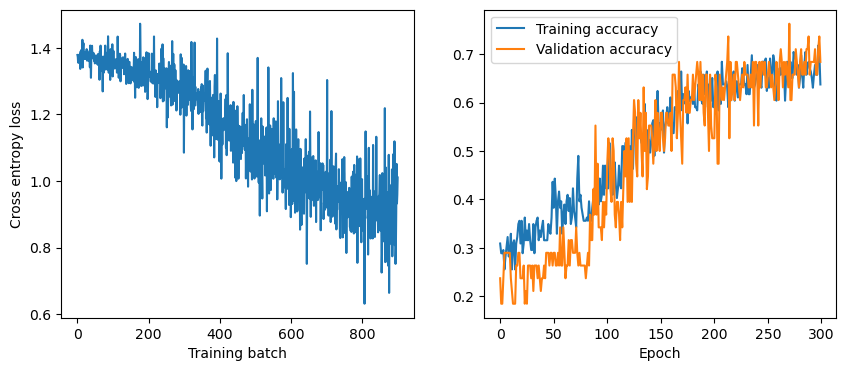

In [9]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
num_epochs = 300

losses = []
train_accs = []
test_accs = []

for epoch in range(num_epochs):
    model.train()
    start_time = time.perf_counter()
    train_loss = 0.0
    train_correct_count = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss_val = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()
        
        losses.append(loss_val.item())
        train_loss += loss_val.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct_count += (predicted == labels).sum().item()

    train_acc = 100 * train_correct_count / train_total
    val_acc = evaluate_metric(model, val_loader, correct) * 100
    
    train_accs.append(train_acc / 100)
    test_accs.append(val_acc / 100)
    
    end_time = time.perf_counter()
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}% | Duration: {end_time - start_time:.3f}s")
    print("-" * 30)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Training batch')
plt.ylabel('Cross entropy loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training accuracy')
plt.plot(test_accs, label='Validation accuracy')
plt.xlabel('Epoch')
plt.legend(loc='best')
plt.show()

In [10]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
num_epochs = 10

losses = []
train_accs = []
test_accs = []


best_val_acc = 0.0
patience = 3    
counter = 0    
best_model_path = 'best_model.pth'


for epoch in range(num_epochs):
    model.train()
    start_time = time.perf_counter()
    train_loss = 0.0
    train_correct_count = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        
        outputs = model(images)
        loss_val = criterion(outputs, labels)
        
        
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()
        
        
        losses.append(loss_val.item())
        train_loss += loss_val.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct_count += (predicted == labels).sum().item()

    
    model.eval() 
    with torch.no_grad():
        val_acc_raw = evaluate_metric(model, val_loader, correct)
        val_acc = val_acc_raw * 100
    
    train_acc = 100 * train_correct_count / train_total
    train_accs.append(train_acc / 100)
    test_accs.append(val_acc_raw)
    
    end_time = time.perf_counter()
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}% | Duration: {end_time - start_time:.3f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"--> Best model saved (Val Acc: {val_acc:.2f}%)")
    else:
        counter += 1
        print(f"No improvement for {counter} epoch(s).")
    
    if counter >= patience:
        print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}")
        break
    print("-" * 30)

model.load_state_dict(torch.load(best_model_path))
print(f"\nLoaded best model with Validation Accuracy: {best_val_acc:.2f}%")

Epoch [1/10]
Train Loss: 0.8554 | Train Acc: 69.80%
Val Acc: 71.05% | Duration: 2.223s
--> Best model saved (Val Acc: 71.05%)
------------------------------
Epoch [2/10]
Train Loss: 0.9038 | Train Acc: 65.77%
Val Acc: 71.05% | Duration: 2.162s
No improvement for 1 epoch(s).
------------------------------
Epoch [3/10]
Train Loss: 0.9219 | Train Acc: 69.80%
Val Acc: 65.79% | Duration: 2.020s
No improvement for 2 epoch(s).
------------------------------
Epoch [4/10]
Train Loss: 0.9756 | Train Acc: 66.44%
Val Acc: 65.79% | Duration: 1.872s
No improvement for 3 epoch(s).

Early stopping triggered! Training stopped at epoch 4

Loaded best model with Validation Accuracy: 71.05%


C:\Users\kiera\AppData\Local\Temp\ipykernel_26240\2610008507.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [11]:
model.eval()

with torch.no_grad():
    test_acc = evaluate_metric(model, test_loader, correct)

print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

Final Test Accuracy: 53.49%
